<img src="logos/logo_Facyt.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Dataset de Pokemon - Analisis Exploratorio de Datos Profesional

## Contexto del proyecto

Este notebook presenta un analisis exploratorio de datos riguroso sobre el dataset de Pokemon, compuesto por una pokedex en CSV y un registro de combates en CSV.

El objetivo no es solo describir los datos, sino identificar de forma sistematica:

- patrones estructurales,
- problemas de calidad de datos,
- mecanismos de faltantes,
- interacciones entre variables,
- oportunidades de ingenieria de variables,
- y riesgos para el modelado.

El problema de interes es la prediccion del ganador en combates 1 vs 1 entre Pokemon.

El dataset incluye:

- una pokedex con identificador, nombre, stats base, generacion y condicion de legendario,
- un registro de combates con `First_pokemon`, `Second_pokemon` y `Winner`.

Este EDA esta diseñado como base para un pipeline completo de Machine Learning.

---

## Definicion del problema

Buscamos predecir el resultado del combate usando informacion estructurada de ambos Pokemon transformada a nivel combate.
- **Tipo de tarea**: clasificacion binaria
- **Variable objetivo operativa**: `first_wins`

---

## Estandar metodologico

Este analisis sigue practicas profesionales de ciencia de datos:

- estructura reproducible,
- decisiones cuantificadas,
- tratamiento explicito de datos faltantes,
- distincion clara entre tipos de variables,
- identificacion de efectos de interaccion,
- conexion directa con decisiones de modelado.

Cada bloque analitico debe cerrar con implicaciones accionables para el pipeline.

---

## Principio rector

Si un analisis no produce una decision de modelado, no deberia ocupar un lugar central en el notebook.

El objetivo es reducir incertidumbre y preparar una estrategia de preprocesamiento robusta,
no producir visualizaciones decorativas.

---

## Resultados esperados

Al finalizar este notebook deberiamos haber:

1. evaluado la calidad de los datos,
2. identificado los predictores dominantes,
3. descrito relaciones entre atributos y resultado,
4. diagnosticado mecanismos de faltantes,
5. detectado relaciones no lineales relevantes,
6. identificado riesgos del dataset,
7. propuesto transformaciones justificadas,
8. definido una hoja de ruta de preprocesamiento para modelado.

Este documento busca funcionar como una referencia profesional de EDA orientado a prediccion.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 29

DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")
FIG_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)

In [19]:
pokemon_path = DATA_DIR / "pokemon.csv"
pokemon_df = pd.read_csv(pokemon_path)

combat_path = DATA_DIR / "combats.csv"
combat_df = pd.read_csv(combat_path)

print(f"Forma del dataset de Pokemon: {pokemon_df.shape}")
print(pokemon_df.head())

print(f"Forma del dataset de combates: {combat_df.shape}")
print(combat_df.head())


Forma del dataset de Pokemon: (800, 12)
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Generation  Legendary
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65     45           1      False
1  2        Ivysaur  Grass  Poison  60      62       63       80       80     60           1      False
2  3       Venusaur  Grass  Poison  80      82       83      100      100     80           1      False
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120     80           1      False
4  5     Charmander   Fire     NaN  39      52       43       60       50     65           1      False
Forma del dataset de combates: (50000, 3)
   First_pokemon  Second_pokemon  Winner
0            266             298     298
1            702             701     701
2            191             668     668
3            237             683     683
4            151             231     151


# EDA de combates Pokemon - Enfoque profesional
## Objetivo
Realizar un analisis exploratorio riguroso para entender el dataset de Pokemon y justificar decisiones de preprocesamiento para un futuro modelo de clasificacion.
- Evaluar si las stats base de los Pokemon funcionan como predictores positivos del resultado del combate.
## Variable objetivo
`Winner` se transforma en una formulacion binaria a nivel combate:
$$ Y= \begin{cases}
1, \text{si} \quad Winner = FirstPokemon\\
0, \text{si} \quad Winner = SecondPokemon
\end{cases}
$$
## Preguntas rectoras
1. El Pokemon ubicado en primera posicion gana mas veces que el segundo?
2. Que stat tiene mayor asociacion con la victoria?
3. Existe una relacion positiva entre `Speed` y la probabilidad de ganar?
4. Es `Attack` fisico mas decisivo que `Sp. Atk` en este dataset?
5. Cual es el win rate de Pokemon legendarios frente a no legendarios, y de megaevolucionados frente a no megaevolucionados?
6. Que combinaciones de `Type 1` muestran mejor rendimiento historico?
7. Que impacto tiene la generacion sobre la probabilidad de victoria?
8. Existen variables de alta cardinalidad que puedan introducir ruido?
9. Que riesgos pueden afectar el modelado, como desbalance, sesgo por faltantes o leakage?

## Data Audit

In [4]:
pokemon_df.info()
combat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 69.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null

A partir de la auditoria inicial se distinguen los siguientes tipos de variables:

- Variables numericas reales en `pokemon_df`:
  - `HP`
  - `Attack`
  - `Defense`
  - `Sp. Atk`
  - `Sp. Def`
  - `Speed`

- Variables enteras con posible rol identificador o categorico:
  - En `pokemon_df`: `#`, `Generation`, `Legendary`
  - En `combat_df`: `First_pokemon`, `Second_pokemon`

- Variables de texto con potencial categorico o semantico:
  - `Name`
  - `Type 1`
  - `Type 2`

La variable objetivo original es:

- `Winner`, que luego se transforma a una representacion binaria a nivel combate.

In [20]:
print('\nPorcentaje de faltantes en pokemon_df:')
display((pokemon_df.isna().mean().sort_values(ascending=False) * 100).round(2).to_frame('missing_%'))

print('Porcentaje de faltantes en combat_df:')
display((combat_df.isna().mean().sort_values(ascending=False) * 100).round(2).to_frame('missing_%'))

print('Duplicados en pokemon_df:', pokemon_df.duplicated().sum())
print('Duplicados en combat_df:', combat_df.duplicated().sum())

print('Porcentaje de duplicados en combat_df:', (combat_df.duplicated().mean() * 100).round(2))


Porcentaje de faltantes en pokemon_df:


,missing_%
Type 2,48.25
#,0.00
Name,0.00
Type 1,0.00
HP,0.00
Attack,0.00
Defense,0.00
Sp. Atk,0.00
Sp. Def,0.00
Speed,0.00


Porcentaje de faltantes en combat_df:


,missing_%
First_pokemon,0.0
Second_pokemon,0.0
Winner,0.0


Duplicados en pokemon_df: 0
Duplicados en combat_df: 1952
Porcentaje de duplicados en combat_df: 3.9


`Type2` is the variable with the largest number of values ​​and  the only one with null values. This is because `Type2` is the secondary type that is combined with `Type1`.

### Profundizacion en cardinalidad (Data Audit, sin target)

Este bloque complementa la cardinalidad basica sin usar `Winner`:
- Cardinalidad por tabla (`pokemon` y `combats`).
- Cobertura de IDs de combates en la pokedex.
- Frecuencia de aparicion por Pokemon (long tail).

Estas metricas se usan para decisiones estructurales preliminares.

In [21]:
card_pokemon = pokemon_df.nunique().sort_values(ascending=False).to_frame('pokemon_nunique')
card_combats = combat_df.nunique().sort_values(ascending=False).to_frame('combats_nunique')

print('Cardinalidad - pokemon_df')
display(card_pokemon)

print('Cardinalidad - combat_df')
display(card_combats)

# Cobertura de IDs de combate dentro de la pokedex
pokemon_ids = set(pokemon_df['#'].astype(int))
combat_ids = set(combat_df['First_pokemon']).union(set(combat_df['Second_pokemon']))
coverage = len(combat_ids.intersection(pokemon_ids)) / len(combat_ids) * 100
print(f'Cobertura de IDs de combate en la pokedex: {coverage:.2f}%')

Cardinalidad - pokemon_df


,pokemon_nunique
#,800
Name,800
Attack,111
Speed,108
Sp. Atk,105
Defense,103
HP,94
Sp. Def,92
Type 2,18
Type 1,18


Cardinalidad - combat_df


,combats_nunique
First_pokemon,784
Second_pokemon,784
Winner,783


Cobertura de IDs de combate en la pokedex: 100.00%


- En `pokemon_df`, las variables `#` y `Name` tienen cardinalidad maxima y actuan como identificadores de entidad; no deben usarse como variables categoricas crudas en un modelo porque introducirian ruido y alta dimensionalidad.

- Las stats base (`HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`) presentan cardinalidad intermedia, consistente con variables cuantitativas y no con categorias.

- `Type 1` y `Type 2` tienen 18 categorias unicas, una cardinalidad manejable para codificacion posterior. Aun asi, `Type 2` requiere tratamiento especial por sus valores nulos estructurales.

- `Generation` tiene solo 6 categorias y `Legendary` solo 2, por lo que ambas son variables de baja cardinalidad aptas para comparacion y para uso potencial como features auxiliares.

- En `combat_df`, `First_pokemon` y `Second_pokemon` tienen cardinalidad muy alta, propia de identificadores. Esto refuerza que no deben modelarse como variables nominales directas, sino como soporte para derivar informacion estructural.

- `Winner` tiene una cardinalidad apenas menor que la de los participantes, lo que sugiere que al menos un Pokemon participa en combates pero no registra victorias.

- La cobertura de IDs entre combates y pokedex es del 100%, por lo que no se observan inconsistencias estructurales entre ambas tablas.

### Conteo de combates y WinRate
Se agregaron `WinRate`, `Wins` y `n_combats` como metricas historicas descriptivas para explorar si ciertos atributos de Pokemon se asocian con mejor rendimiento competitivo.

In [7]:
# Total de apariciones por Pokémon (primera + segunda posición)
appear_first = combat_df["First_pokemon"].value_counts()
appear_second = combat_df["Second_pokemon"].value_counts()
appear_total = appear_first.add(appear_second, fill_value=0)

# Total de victorias por Pokémon
wins = combat_df["Winner"].value_counts()

# Nuevo dataframe con métricas de batalla
pokemon_battles_df = pokemon_df.copy()
pokemon_battles_df["n_combats"] = pokemon_battles_df["#"].map(appear_total).fillna(0).astype(int)
pokemon_battles_df["Wins"] = pokemon_battles_df["#"].map(wins).fillna(0).astype(int)
pokemon_battles_df["WinRate"] = (
    np.where(
        pokemon_battles_df["n_combats"] > 0,
        pokemon_battles_df["Wins"] / pokemon_battles_df["n_combats"] * 100,
        0
    )
).round(2)
pokemon_battles_df.head(10)

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,n_combats,Wins,WinRate
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133,37,27.82
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121,46,38.02
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132,89,67.42
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125,70,56.00
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,112,55,49.11
5,6,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False,118,64,54.24
6,7,Charizard,Fire,Flying,78,84,78,109,85,100,1,False,133,115,86.47
7,8,Mega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False,139,119,85.61
8,9,Mega Charizard Y,Fire,Flying,78,104,78,159,115,100,1,False,135,114,84.44
9,10,Squirtle,Water,NaN,44,48,65,50,64,43,1,False,117,19,16.24


In [22]:
print("Media de n_combats: " + str(pokemon_battles_df["n_combats"].mean()))
print("Media de WinRate: " + str(pokemon_battles_df["WinRate"].mean().round(2)))
print('Top 10 de Pokemon por WinRate')
print(pokemon_battles_df[['#', 'Name', 'n_combats', 'WinRate']].sort_values(by='WinRate', ascending=False).head(10))

Media de n_combats: 125.0
Media de WinRate: 49.09
Top 10 de Pokemon por WinRate
       #                      Name  n_combats  WinRate
154  155           Mega Aerodactyl        129    98.45
512  513                   Weavile        119    97.48
703  704    Tornadus Therian Forme        125    96.80
19    20             Mega Beedrill        119    96.64
153  154                Aerodactyl        141    96.45
476  477              Mega Lopunny        129    96.12
726  727                  Greninja        127    96.06
716  717  Meloetta Pirouette Forme        123    95.93
164  165             Mega Mewtwo Y        125    95.20
349  350             Mega Sharpedo        120    95.00


- La tabla de Pokemon con mayor `WinRate` permite identificar perfiles historicamente eficientes, es decir, Pokemon que convierten una mayor proporcion de apariciones en victorias.

- Sin embargo, `WinRate` no debe interpretarse de forma aislada: siempre debe leerse junto con `Wins` y `n_combats` para distinguir eficiencia real de simple volumen de participacion.

- En este caso, la combinacion de muchas victorias absolutas y alto porcentaje de victoria sugiere que algunos Pokemon no solo ganan con frecuencia relativa, sino que sostienen ese rendimiento con una exposicion competitiva relevante.

- En el top 10 aparece una fuerte presencia de formas megaevolucionadas. Eso puede ser una señal descriptiva interesante, pero no debe leerse como evidencia causal por si sola.

- La comparacion conjunta entre victorias y numero de combates permite separar dos fenomenos distintos:

- Pokemon con alta participacion pero rendimiento medio.

- Pokemon con alto rendimiento competitivo y, al mismo tiempo, resultados absolutos solidos.

- Esta distincion es importante porque un Pokemon con muchos combates no necesariamente es dominante, y uno con alto `WinRate` puede ser poco representativo si su exposicion es reducida.

- Como criterio analitico, los Pokemon que combinan alto `WinRate`, muchas victorias y un numero suficiente de combates son mejores candidatos para representar patrones competitivos estables.

- Desde la perspectiva de modelado, estos resultados sugieren que existen atributos estructurales capaces de explicar la victoria, como stats base, condicion de legendario, tipos, velocidad y formas especiales.

- Metodologicamente, `WinRate` es util para EDA, pero no debe incorporarse como feature directa si fue calculado con toda la base de combates, porque introduciria leakage del target.

- En sintesis:

    - `WinRate` resume eficiencia competitiva historica,

    - `Wins` y `n_combats` aportan contexto de volumen y consistencia,

    - pero ninguna de estas metricas debe pasar al entrenamiento final si se calcula sobre toda la historia observada.

### Descripcion estructural de Pokemon
Graficos y visualizaciones de cantidad de Pokemon por tipo y generacion, distribucion de legendarios y megaevoluciones, y valores minimos y maximos de las stats base.

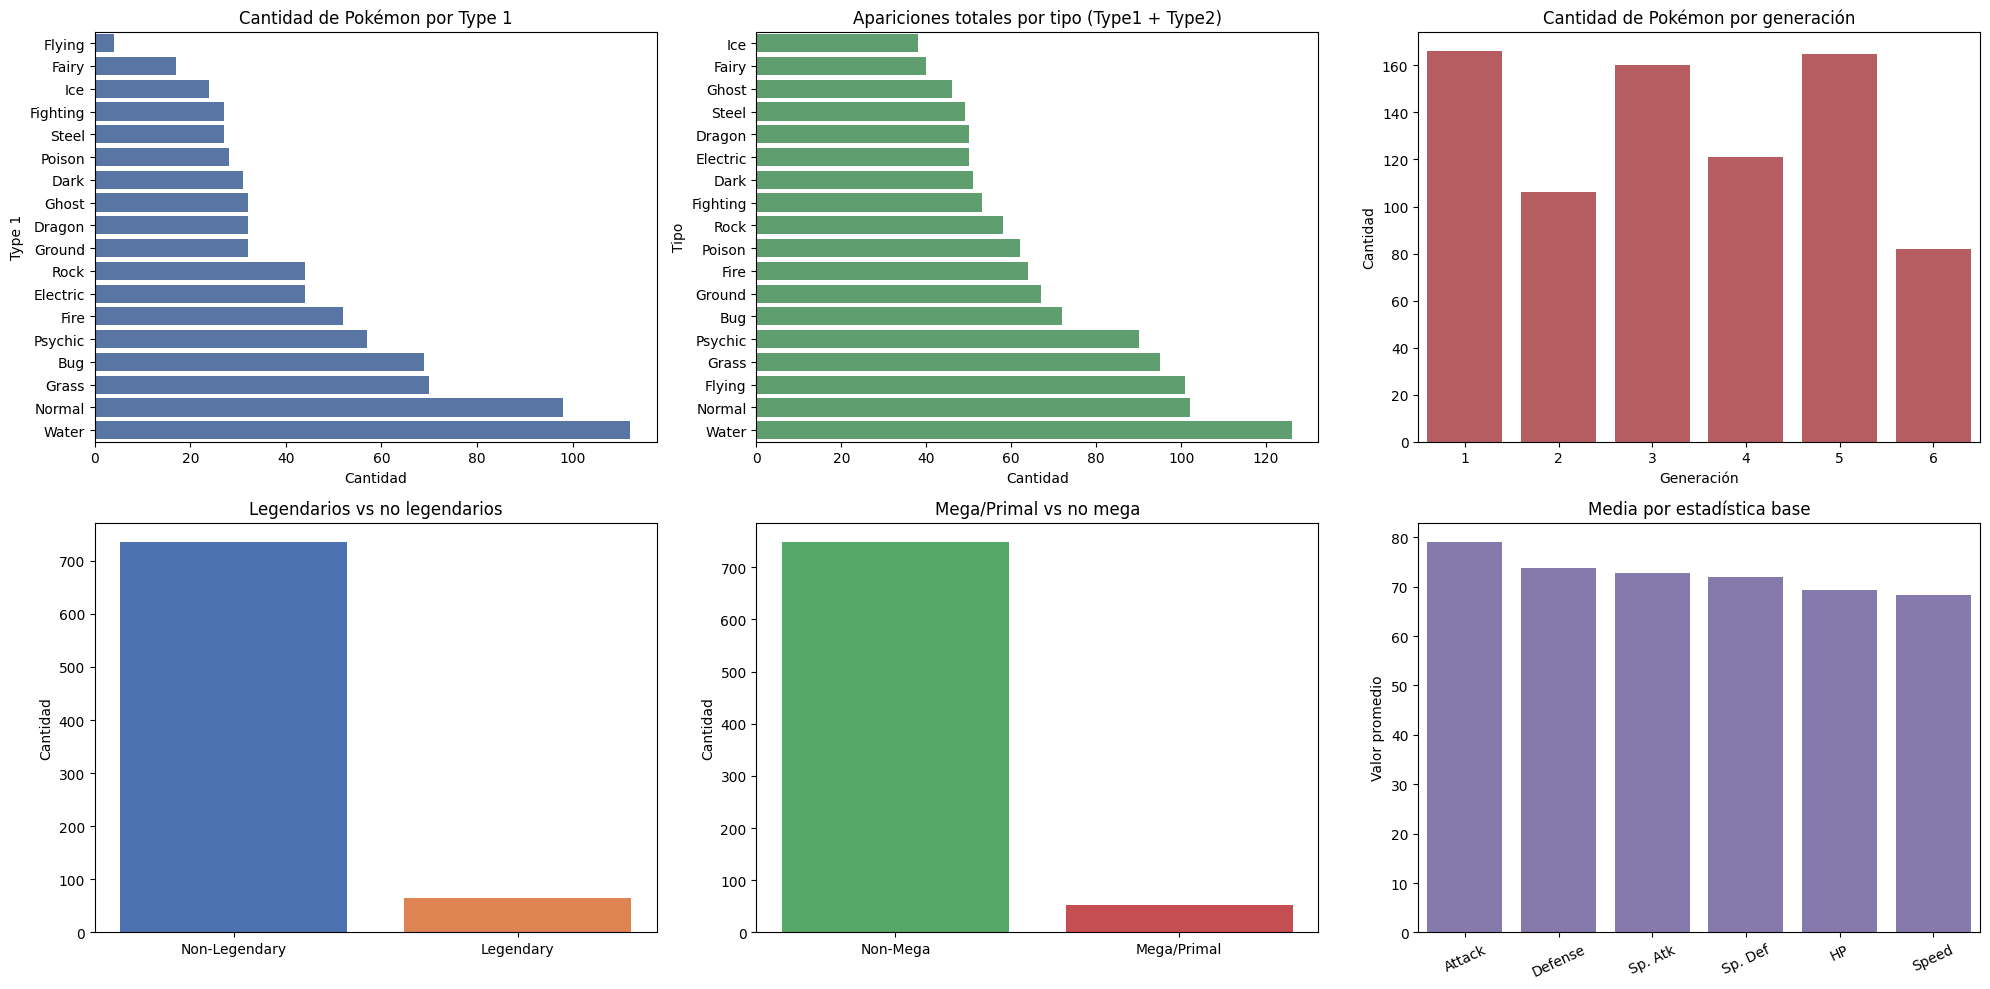

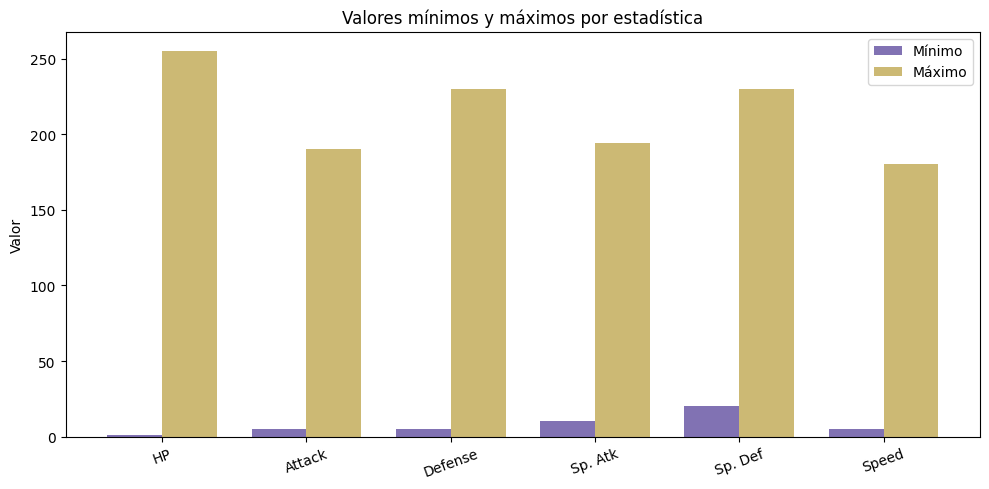

,stat,min_value,pokemon_min (hasta 5),max_value,pokemon_max (hasta 5)
0,HP,1,Shedinja,255,Blissey
1,Attack,5,"Chansey, Happiny",190,Mega Mewtwo X
2,Defense,5,"Chansey, Happiny",230,"Mega Steelix, Shuckle, Mega Aggron"
3,Sp. Atk,10,"Shuckle, Feebas, Bonsly",194,Mega Mewtwo Y
4,Sp. Def,20,"Caterpie, Weedle, Magikarp, Igglybuff, Carvanha",230,Shuckle
5,Speed,5,"Shuckle, Munchlax",180,Deoxys Speed Forme


In [18]:
# Visualizaciones descriptivas: tipos, generación, legendarios, megas y extremos de stats

eda_df = pokemon_df.copy()

# Flag de mega (incluye variantes comunes como Mega/Primal)
eda_df["is_mega"] = eda_df["Name"].str.contains(r"Mega|Primal", case=False, na=False)

# Stats base
stats_cols_local = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

# Conteos
type1_counts = eda_df["Type 1"].value_counts().sort_values(ascending=True)
all_type_counts = (
    pd.concat([eda_df["Type 1"], eda_df["Type 2"].dropna()], axis=0)
    .value_counts()
    .sort_values(ascending=True)
)
generation_counts = eda_df["Generation"].value_counts().sort_index()
legendary_counts = eda_df["Legendary"].map({True: "Legendary", False: "Non-Legendary"}).value_counts()
mega_counts = eda_df["is_mega"].map({True: "Mega/Primal", False: "Non-Mega"}).value_counts()

# ---- Figura 1: distribución general ----
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.barplot(x=type1_counts.values, y=type1_counts.index, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Cantidad de Pokémon por Type 1")
axes[0, 0].set_xlabel("Cantidad")
axes[0, 0].set_ylabel("Type 1")

sns.barplot(x=all_type_counts.values, y=all_type_counts.index, ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Apariciones totales por tipo (Type1 + Type2)")
axes[0, 1].set_xlabel("Cantidad")
axes[0, 1].set_ylabel("Tipo")

sns.barplot(x=generation_counts.index, y=generation_counts.values, ax=axes[0, 2], color="#C44E52")
axes[0, 2].set_title("Cantidad de Pokémon por generación")
axes[0, 2].set_xlabel("Generación")
axes[0, 2].set_ylabel("Cantidad")

axes[1, 0].bar(legendary_counts.index, legendary_counts.values, color=["#4C72B0", "#DD8452"])
axes[1, 0].set_title("Legendarios vs no legendarios")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Cantidad")

axes[1, 1].bar(mega_counts.index, mega_counts.values, color=["#55A868", "#C44E52"])
axes[1, 1].set_title("Mega/Primal vs no mega")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Cantidad")

# Stats resumen rápido (media por stat)
stat_means = eda_df[stats_cols_local].mean().sort_values(ascending=False)
sns.barplot(x=stat_means.index, y=stat_means.values, ax=axes[1, 2], color="#8172B3")
axes[1, 2].set_title("Media por estadística base")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Valor promedio")
axes[1, 2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(FIG_DIR / "pokemon_distribuciones_generales.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Figura 2: máximos y mínimos por stat ----
extremes_df = pd.DataFrame({
    "stat": stats_cols_local,
    "min_value": [eda_df[s].min() for s in stats_cols_local],
    "max_value": [eda_df[s].max() for s in stats_cols_local],
})

x = np.arange(len(extremes_df))
w = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x - w / 2, extremes_df["min_value"], width=w, label="Mínimo", color="#8172B3")
plt.bar(x + w / 2, extremes_df["max_value"], width=w, label="Máximo", color="#CCB974")
plt.xticks(x, extremes_df["stat"], rotation=20)
plt.ylabel("Valor")
plt.title("Valores mínimos y máximos por estadística")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "pokemon_stats_min_max.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Tabla: Pokémon con mínimo y máximo por stat ----
rows = []
for s in stats_cols_local:
    min_val, max_val = eda_df[s].min(), eda_df[s].max()
    min_names = ", ".join(eda_df.loc[eda_df[s] == min_val, "Name"].astype(str).head(5).tolist())
    max_names = ", ".join(eda_df.loc[eda_df[s] == max_val, "Name"].astype(str).head(5).tolist())
    rows.append({
        "stat": s,
        "min_value": min_val,
        "pokemon_min (hasta 5)": min_names,
        "max_value": max_val,
        "pokemon_max (hasta 5)": max_names,
    })

stats_extreme_pokemon_df = pd.DataFrame(rows)
display(stats_extreme_pokemon_df)

## Decisiones estructurales preliminares
### Pokemon
- `#` y `Name` son campos de identidad de alta cardinalidad; no deben usarse como variables nominales crudas.
- `Type 1`, `Type 2`, `Legendary` y `Generation` son variables categoricas con valor estructural.
- Las stats de combate (`HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`) deben tratarse como predictores cuantitativos.

### Combates
- `First_pokemon`, `Second_pokemon` y `Winner` son identificadores de entidad por diseño.
- Los combates duplicados (~3.9%) indican matchups repetidos y posible sesgo de representacion.
- Recomendacion para la etapa de preparacion: remover duplicados exactos antes del split y validar con un esquema que controle pares de enfrentamiento repetidos.

## Analisis de la variable objetivo

Definicion operativa del target para un EDA orientado a modelado:
- `first_wins = 1` si `Winner == First_pokemon`
- `first_wins = 0` en caso contrario

Este bloque se separa intencionalmente de la auditoria de datos porque depende del resultado del combate.

Distribucion del target:
first_wins
0    52.798
1    47.202
Name: proportion, dtype: float64

Accuracy ingenua baseline: 52.80%
Combates exactos duplicados: 3.90%


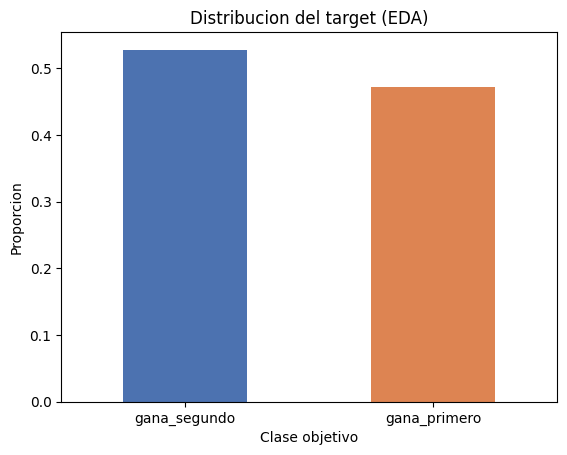

In [25]:
target_df = combat_df.copy()
target_df['first_wins'] = (target_df['Winner'] == target_df['First_pokemon']).astype(int)

target_dist = target_df['first_wins'].value_counts(normalize=True).sort_index()

print('Distribucion del target:')
print(target_dist * 100)


baseline_acc = target_dist.max() *100
print(f'\nAccuracy ingenua baseline: {baseline_acc:.2f}%')
# Duplicados exactos en combates
dup_pct = combat_df.duplicated(subset=['First_pokemon', 'Second_pokemon', 'Winner']).mean() * 100
print(f'Combates exactos duplicados: {dup_pct:.2f}%')
ax = target_dist.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['gana_segundo', 'gana_primero'], rotation=0)
ax.set_xlabel('Clase objetivo')
ax.set_ylabel('Proporcion')
ax.set_title('Distribucion del target (EDA)')
plt.show()

La variable objetivo esta cerca del equilibrio, con una ligera ventaja para la posicion mayoritaria observada en la muestra.

- El target operativo no muestra un desbalance severo de clases.
- Un clasificador ingenuo que siempre prediga la clase mayoritaria obtendria una accuracy cercana a la proporcion de esa clase.
- Por ello, la accuracy baseline por si sola sera insuficiente; conviene complementar con precision, recall, F1, ROC-AUC y estabilidad bajo esquemas de validacion seguros frente a leakage.
- La presencia de combates duplicados debe tratarse como riesgo de dependencia durante validacion, porque los matchups repetidos pueden inflar el rendimiento aparente del modelo.

## Relación entre stats y probabilidad de ganar

Resumen: relación entre ventaja de stat y probabilidad de ganar


,stat,corr_with_first_wins,p1_winrate_if_higher_%,p1_winrate_if_tied_%,p1_winrate_if_lower_%,gap_higher_vs_lower_pp,higher_cases,tie_cases,lower_cases
0,Speed,0.678,92.385,0.000,4.602,87.783,24334,1328,24338
1,Stats_Total,0.470,67.052,44.518,27.216,39.836,24824,602,24574
2,Attack,0.362,62.708,45.380,31.795,30.913,24383,1223,24394
3,Sp. Atk,0.349,62.270,45.977,32.013,30.257,24418,1479,24103
4,Sp. Def,0.219,58.254,45.209,36.179,22.075,24254,1743,24003
5,HP,0.194,58.113,46.091,36.357,21.756,24055,1944,24001
6,Defense,0.079,52.377,45.855,42.076,10.301,24314,1544,24142


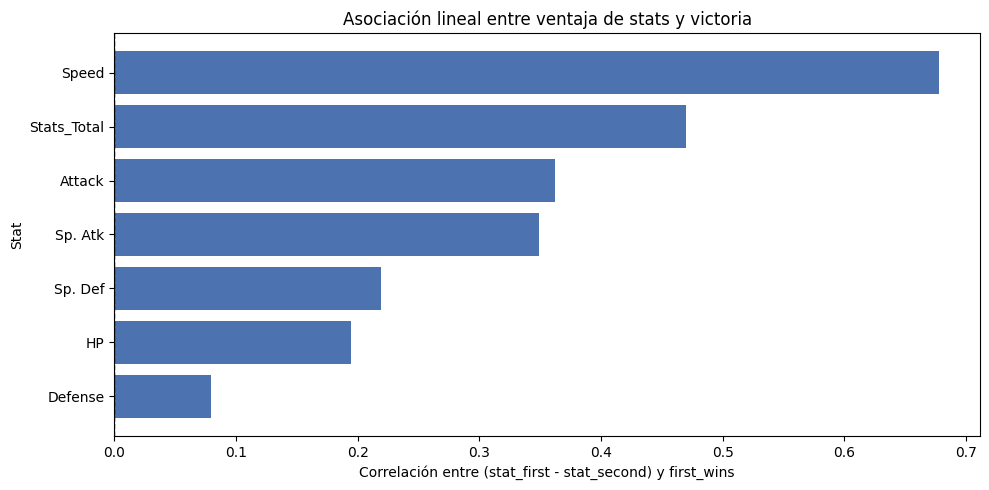

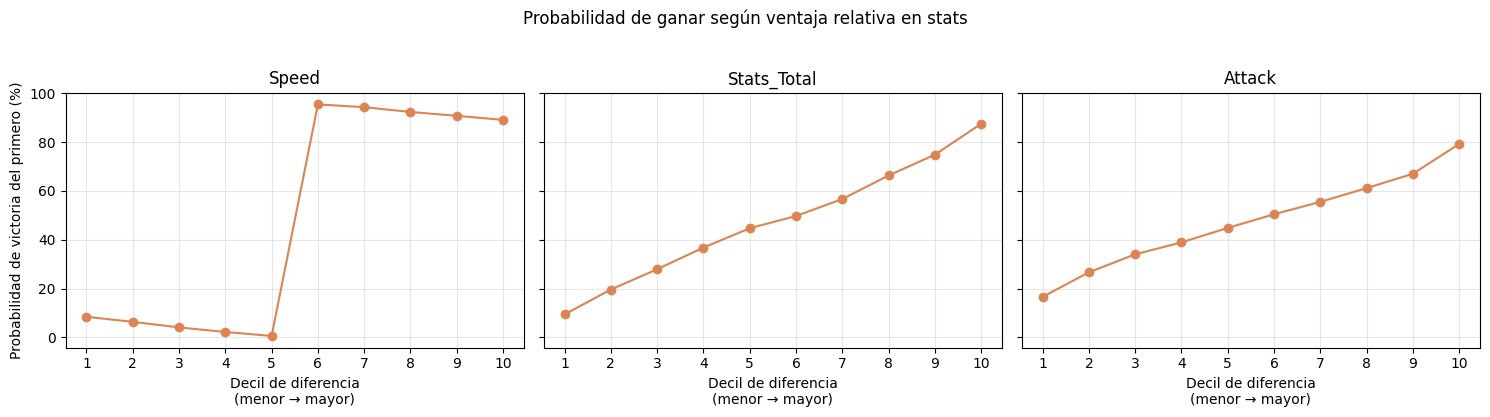

In [11]:
# Usa variables ya existentes: pokemon_df, target_df, FIG_DIR

stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Tabla base de stats por Pokémon
stats_lookup = pokemon_df.set_index('#')[stats_cols].copy()
stats_lookup['Stats_Total'] = stats_lookup.sum(axis=1)
analysis_stats = stats_cols + ['Stats_Total']

# Construcción del dataset de combate a nivel batalla
battle_stats_df = target_df[['First_pokemon', 'Second_pokemon', 'first_wins']].copy()

for stat in analysis_stats:
    battle_stats_df[f'first_{stat}'] = battle_stats_df['First_pokemon'].map(stats_lookup[stat])
    battle_stats_df[f'second_{stat}'] = battle_stats_df['Second_pokemon'].map(stats_lookup[stat])
    battle_stats_df[f'diff_{stat}'] = battle_stats_df[f'first_{stat}'] - battle_stats_df[f'second_{stat}']

# Resumen numérico por stat
summary_rows = []

for stat in analysis_stats:
    diff_col = f'diff_{stat}'
    diff = battle_stats_df[diff_col]

    higher_mask = diff > 0
    tie_mask = diff == 0
    lower_mask = diff < 0

    winrate_higher = battle_stats_df.loc[higher_mask, 'first_wins'].mean() * 100
    winrate_tie = battle_stats_df.loc[tie_mask, 'first_wins'].mean() * 100 if tie_mask.any() else np.nan
    winrate_lower = battle_stats_df.loc[lower_mask, 'first_wins'].mean() * 100

    summary_rows.append({
        'stat': stat,
        'corr_with_first_wins': battle_stats_df[diff_col].corr(battle_stats_df['first_wins']),
        'p1_winrate_if_higher_%': winrate_higher,
        'p1_winrate_if_tied_%': winrate_tie,
        'p1_winrate_if_lower_%': winrate_lower,
        'gap_higher_vs_lower_pp': winrate_higher - winrate_lower,
        'higher_cases': int(higher_mask.sum()),
        'tie_cases': int(tie_mask.sum()),
        'lower_cases': int(lower_mask.sum())
    })

stats_effect_df = (
    pd.DataFrame(summary_rows)
    .sort_values(['gap_higher_vs_lower_pp', 'corr_with_first_wins'], ascending=False)
    .reset_index(drop=True)
)

print('Resumen: relación entre ventaja de stat y probabilidad de ganar')
display(stats_effect_df.round(3))

# Gráfico 1: correlación entre diferencia de stats y victoria del primero
plot_df = stats_effect_df.sort_values('corr_with_first_wins', ascending=True)
plt.figure(figsize=(10, 5))
plt.barh(plot_df['stat'], plot_df['corr_with_first_wins'], color='#4C72B0')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Correlación entre (stat_first - stat_second) y first_wins')
plt.ylabel('Stat')
plt.title('Asociación lineal entre ventaja de stats y victoria')
plt.tight_layout()
plt.savefig(FIG_DIR / 'stats_vs_win_probability_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Gráfico 2: win rate por deciles de diferencia para las 3 stats más influyentes
top_stats = stats_effect_df.head(3)['stat'].tolist()

fig, axes = plt.subplots(1, len(top_stats), figsize=(5 * len(top_stats), 4), sharey=True)
if len(top_stats) == 1:
    axes = [axes]

for ax, stat in zip(axes, top_stats):
    decile_df = battle_stats_df[[f'diff_{stat}', 'first_wins']].copy()
    decile_df = decile_df.rename(columns={f'diff_{stat}': 'diff'})
    decile_df['bin'] = pd.qcut(decile_df['diff'], q=10, duplicates='drop')

    trend = (
        decile_df.groupby('bin', observed=False)['first_wins']
        .mean()
        .mul(100)
        .reset_index()
    )

    ax.plot(range(len(trend)), trend['first_wins'], marker='o', color='#DD8452')
    ax.set_title(stat)
    ax.set_xlabel('Decil de diferencia\n(menor → mayor)')
    ax.set_xticks(range(len(trend)))
    ax.set_xticklabels(range(1, len(trend) + 1))
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Probabilidad de victoria del primero (%)')
fig.suptitle('Probabilidad de ganar según ventaja relativa en stats', y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'stats_vs_win_probability_deciles.png', dpi=150, bbox_inches='tight')
plt.show()

## Heatmap: correlacion entre stats base, stats totales y `WinRate`

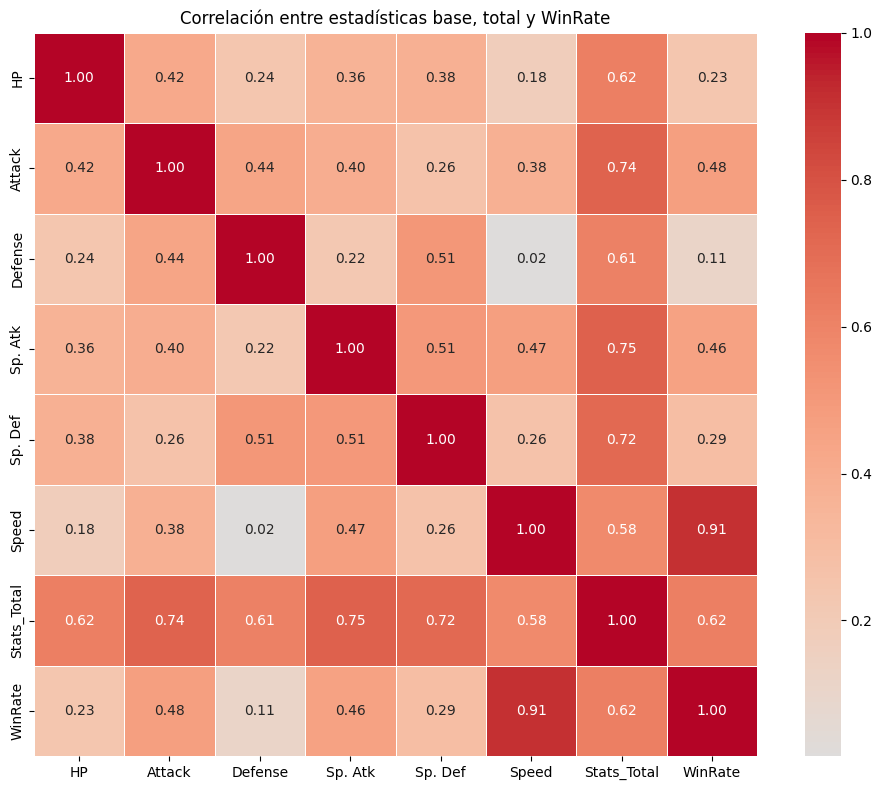

Correlación de cada estadística con WinRate:


,corr_with_WinRate
Speed,0.905410
Stats_Total,0.619735
Attack,0.476671
Sp. Atk,0.455845
Sp. Def,0.291598
HP,0.234886
Defense,0.113308


In [12]:
if 'Stats_Total' not in pokemon_battles_df.columns:
    pokemon_battles_df['Stats_Total'] = pokemon_battles_df[stats_cols].sum(axis=1)

heatmap_cols = stats_cols + ['Stats_Total', 'WinRate']
winrate_corr_matrix = pokemon_battles_df[heatmap_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    winrate_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlación entre estadísticas base, total y WinRate")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_base_stats_total_winrate.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlación de cada estadística con WinRate:")
display(
    winrate_corr_matrix['WinRate']
    .drop('WinRate')
    .sort_values(ascending=False)
    .to_frame('corr_with_WinRate')
)

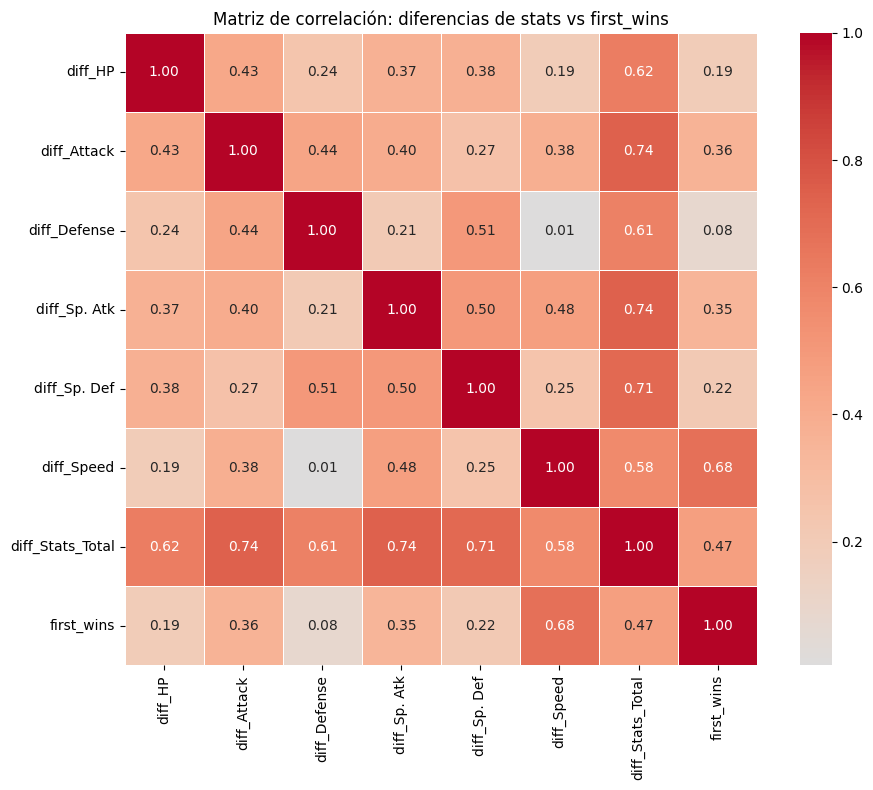

Correlación de cada stat con first_wins:


,corr_with_first_wins
diff_Speed,0.677719
diff_Stats_Total,0.470201
diff_Attack,0.361873
diff_Sp. Atk,0.348891
diff_Sp. Def,0.218823
diff_HP,0.194240
diff_Defense,0.079377


In [13]:
# Matriz de correlación entre diferencias de stats y probabilidad de victoria del primero
corr_cols = [f'diff_{stat}' for stat in analysis_stats] + ['first_wins']

corr_matrix = battle_stats_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matriz de correlación: diferencias de stats vs first_wins")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_matrix_stats_vs_win.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlación de cada stat con first_wins:")
display(
    corr_matrix["first_wins"]
    .drop("first_wins")
    .sort_values(ascending=False)
    .to_frame("corr_with_first_wins")
)

1. **Speed es la stat más determinante del dataset.**  
    Es la que tiene mayor correlación con la victoria y la mayor separación entre casos con ventaja y desventaja. 
    - Tiene la mayor correlación con `WinRate` a nivel Pokémon.
    - Tiene también la mayor correlación con `first_wins` cuando se analiza la **diferencia de stats entre ambos combatientes**.

2. **La ventaja en Speed casi determina el resultado del combate.**  
    Cuando el primer Pokémon tiene más `Speed`, gana aproximadamente **92.39%** de las veces; cuando tiene menos, gana solo **4.60%**. 

3. **`Total` es la segunda variable más fuerte.**  
    Tener mayor suma total de stats también incrementa claramente la probabilidad de victoria, aunque su efecto es bastante menor que el de `Speed`. Mantiene una asociación alta tanto con `WinRate` como con `first_wins`. Si el primero tiene mejores estadísticas en su conjunto, gana 67.05% de las veces; si tiene menor Total, gana 27.22%, lo que indica que la fortaleza global del Pokémon también explica una parte importante del desempeño.

4. **Entre `Attack` y `Sp. Atk`, `Attack` es ligeramente más decisiva.**  
    Ambas tienen poder predictivo parecido, pero `Attack` muestra una ventaja marginalmente superior en separación de probabilidades.

5. **`Defense` es la stat menos influyente del conjunto analizado.**  
    Su correlación con la victoria es baja y la diferencia entre tener ventaja o desventaja es pequeña en comparación con el resto.

6. **Las curvas por deciles muestran una relación monotónica.**  
    En las stats más relevantes, cuanto mayor es la ventaja relativa del primer Pokémon, mayor es su probabilidad de ganar.

7. **Las diferencias entre stats son más informativas que las stats aisladas.**  
    La matriz basada en `diff_HP`, `diff_Attack`, `diff_Speed`, etc., muestra con mayor claridad la relación directa entre ventaja competitiva y resultado del combate.  
    Esto respalda que el modelado debe centrarse en variables relativas entre el primer y segundo Pokémon.

8. **Implicación para feature engineering:**  
    Para un modelo predictivo, conviene construir variables como:
    - `diff_HP`
    - `diff_Attack`
    - `diff_Defense`
    - `diff_Sp. Atk`
    - `diff_Sp. Def`
    - `diff_Speed`
    - `diff_Total`
    
    Sin embargo, las variables con mayor valor analítico para el modelo son:
    - `diff_Speed`
    - `diff_Stats_Total`
    - `diff_Attack`
    - `diff_Sp. Atk`

    En cambio, `diff_Defense` tendría menor prioridad relativa.

    porque capturan directamente la ventaja competitiva entre ambos participantes.
9. **Riesgo analítico importante:**  
    El comportamiento extremo de `Speed` sugiere una señal muy fuerte del dataset, pero también amerita revisión metodológica para confirmar que no existan sesgos de generación de combates o reglas implícitas que favorezcan excesivamente a la velocidad.

## Analisis comparativo: legendarios vs no legendarios, mega vs no mega
Analisis descriptivo comparativo entre grupos de Pokemon para evaluar asociaciones historicas con la victoria y distinguir senal bruta de posible confounding por stats base.

Combates originales: 50,000
Combates deduplicados: 48,048
Duplicados removidos: 1,952 (3.90%)
Resumen por grupo (historico descriptivo)


,pokemon_count,avg_winrate_hist,median_winrate_hist,avg_wins,avg_combats,avg_total_stats,avg_speed,legendary_rate,mega_rate
profile_group,,,,,,,,,
Normal,691,45.13,43.54,57.41,124.67,405.80,63.86,0.0,0.0
Mega,44,70.42,79.00,89.89,128.73,596.41,90.45,0.0,1.0
Legendary,59,76.70,79.70,98.19,128.05,626.95,98.25,1.0,0.0
Legendary + Mega,6,76.82,91.20,97.33,105.50,740.00,119.17,1.0,1.0


Resumen: legendarios vs no legendarios


,pokemon_count,avg_winrate_hist,median_winrate_hist,avg_total_stats,avg_speed
Legendary,,,,,
Non-Legendary,735,46.64,44.83,417.21,65.46
Legendary,65,76.72,81.34,637.38,100.18


Resumen: mega vs no mega


...

opponent,Normal,Mega,Legendary,Legendary + Mega
group,,,,
Normal,50.00,26.70,18.85,5.54
Mega,73.30,50.00,45.48,25.00
Legendary,81.15,54.52,50.00,14.00
Legendary + Mega,94.46,75.00,86.00,50.00


Cantidad de enfrentamientos por grupo


opponent,Normal,Mega,Legendary,Legendary + Mega
group,,,,
Normal,71272,4700,6259,523
Mega,4700,306,409,32
Legendary,6259,409,566,50
Legendary + Mega,523,32,50,6


Top enfrentamientos dirigidos por volumen y tasa de victoria


,group,opponent,n_battles,win_rate_pct
3,Legendary,Normal,6259,81.15
12,Normal,Legendary,6259,18.85
11,Mega,Normal,4700,73.30
14,Normal,Mega,4700,26.70
7,Legendary + Mega,Normal,523,94.46
13,Normal,Legendary + Mega,523,5.54
2,Legendary,Mega,409,54.52
8,Mega,Legendary,409,45.48
4,Legendary + Mega,Legendary,50,86.00
1,Legendary,Legendary + Mega,50,14.00


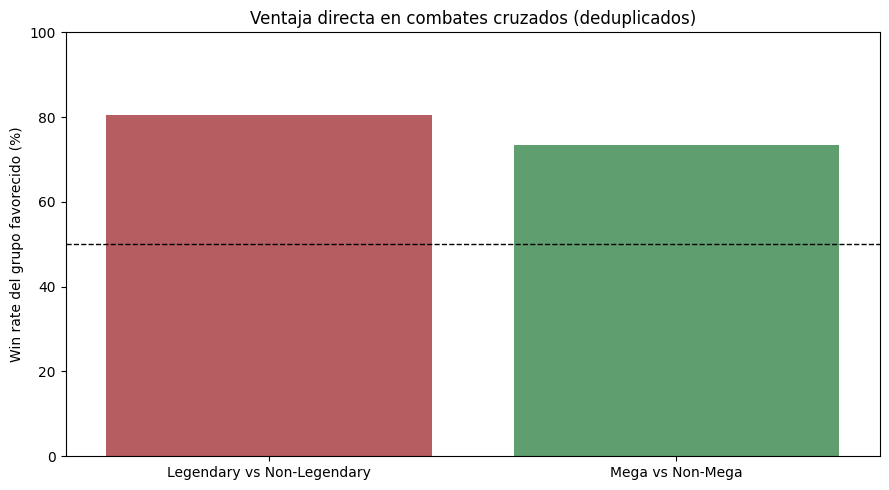

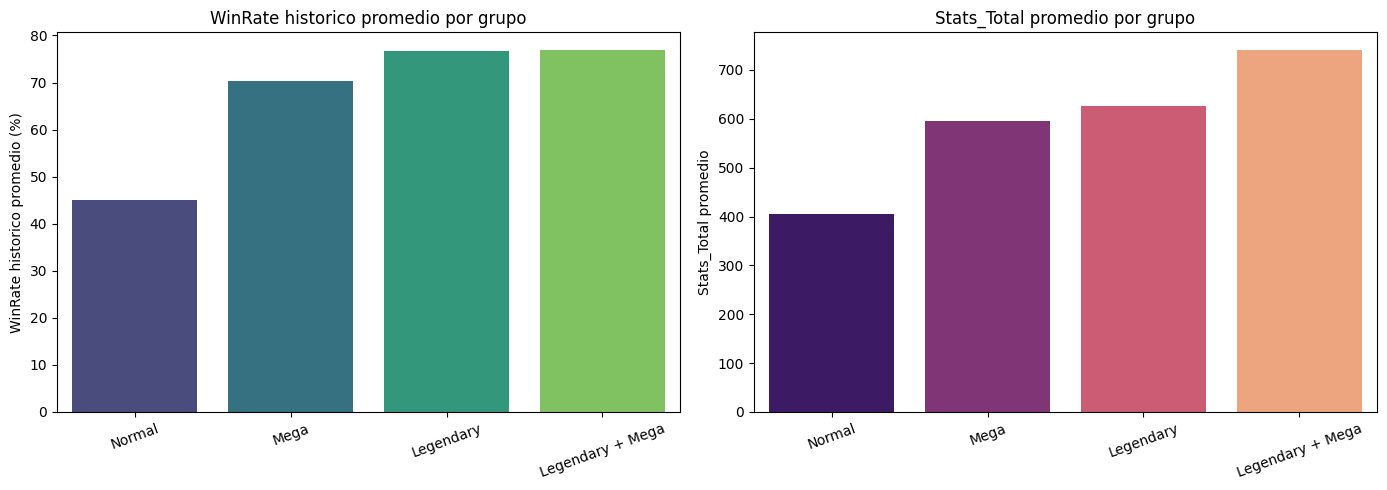

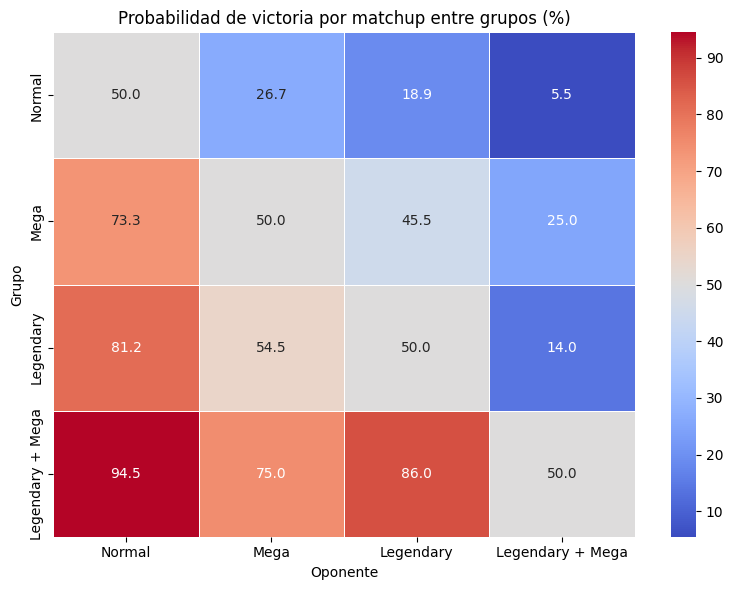

In [ ]:
# ---------- Funciones auxiliares ----------
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p_hat = successes / n
    denom = 1 + (z ** 2) / n
    center = (p_hat + (z ** 2) / (2 * n)) / denom
    margin = (z / denom) * np.sqrt((p_hat * (1 - p_hat) / n) + (z ** 2) / (4 * (n ** 2)))
    return center - margin, center + margin


def summarize_advantaged_winrate(df, label, advantaged_label):
    n = len(df)
    wins = int(df["advantaged_wins"].sum())
    p = wins / n if n > 0 else np.nan
    low, high = wilson_ci(wins, n)
    return {
        "comparison": label,
        "n_battles": n,
        "advantaged_group": advantaged_label,
        "advantaged_group_winrate_%": p * 100 if n > 0 else np.nan,
        "ci95_low_%": low * 100 if n > 0 else np.nan,
        "ci95_high_%": high * 100 if n > 0 else np.nan,
        "other_group_winrate_%": (1 - p) * 100 if n > 0 else np.nan,
    }


# ---------- 1) Base de Pokemon con perfiles ----------
pokemon_profile_df = pokemon_battles_df.copy()

# El dataset usa nombres con variaciones de mega; este criterio textual es aproximado.
pokemon_profile_df["is_mega"] = pokemon_profile_df["Name"].str.contains("Mega", case=False, na=False)

pokemon_profile_df["profile_group"] = np.select(
    [
        pokemon_profile_df["Legendary"] & pokemon_profile_df["is_mega"],
        pokemon_profile_df["Legendary"] & ~pokemon_profile_df["is_mega"],
        ~pokemon_profile_df["Legendary"] & pokemon_profile_df["is_mega"],
    ],
    ["Legendary + Mega", "Legendary", "Mega"],
    default="Normal",
)

group_order = ["Normal", "Mega", "Legendary", "Legendary + Mega"]

pokemon_group_summary = (
    pokemon_profile_df.groupby("profile_group", observed=False)
    .agg(
        pokemon_count=("#", "count"),
        avg_winrate_hist=("WinRate", "mean"),
        median_winrate_hist=("WinRate", "median"),
        avg_wins=("Wins", "mean"),
        avg_combats=("n_combats", "mean"),
        avg_total_stats=("Stats_Total", "mean"),
        avg_speed=("Speed", "mean"),
        legendary_rate=("Legendary", "mean"),
        mega_rate=("is_mega", "mean"),
    )
    .reindex(group_order)
    .round(2)
)

legendary_summary = (
    pokemon_profile_df.groupby("Legendary")
    .agg(
        pokemon_count=("#", "count"),
        avg_winrate_hist=("WinRate", "mean"),
        median_winrate_hist=("WinRate", "median"),
        avg_total_stats=("Stats_Total", "mean"),
        avg_speed=("Speed", "mean"),
    )
    .rename(index={False: "Non-Legendary", True: "Legendary"})
    .round(2)
)

mega_summary = (
    pokemon_profile_df.groupby("is_mega")
    .agg(
        pokemon_count=("#", "count"),
        avg_winrate_hist=("WinRate", "mean"),
        median_winrate_hist=("WinRate", "median"),
        avg_total_stats=("Stats_Total", "mean"),
        avg_speed=("Speed", "mean"),
    )
    .rename(index={False: "Non-Mega", True: "Mega"})
    .round(2)
)


# ---------- 2) Base de combates deduplicada (sensibilidad a sesgo por repeticion) ----------
combat_model_df = combat_df.drop_duplicates(subset=["First_pokemon", "Second_pokemon", "Winner"]).copy()
removed_duplicates = len(combat_df) - len(combat_model_df)
print(f"Combates originales: {len(combat_df):,}")
print(f"Combates deduplicados: {len(combat_model_df):,}")
print(f"Duplicados removidos: {removed_duplicates:,} ({removed_duplicates / len(combat_df) * 100:.2f}%)")

battle_group_df = combat_model_df[["First_pokemon", "Second_pokemon", "Winner"]].copy()
battle_group_df["first_wins"] = (battle_group_df["Winner"] == battle_group_df["First_pokemon"]).astype(int)

legend_lookup = pokemon_profile_df.set_index("#")["Legendary"]
mega_lookup = pokemon_profile_df.set_index("#")["is_mega"]
profile_lookup = pokemon_profile_df.set_index("#")["profile_group"].astype(str)
speed_lookup = pokemon_profile_df.set_index("#")["Speed"]
total_lookup = pokemon_profile_df.set_index("#")["Stats_Total"]

battle_group_df["first_legendary"] = battle_group_df["First_pokemon"].map(legend_lookup)
battle_group_df["second_legendary"] = battle_group_df["Second_pokemon"].map(legend_lookup)
battle_group_df["first_mega"] = battle_group_df["First_pokemon"].map(mega_lookup)
battle_group_df["second_mega"] = battle_group_df["Second_pokemon"].map(mega_lookup)
battle_group_df["first_group"] = battle_group_df["First_pokemon"].map(profile_lookup)
battle_group_df["second_group"] = battle_group_df["Second_pokemon"].map(profile_lookup)

# Confusores fuertes detectados en el EDA previo
battle_group_df["diff_speed"] = (
    battle_group_df["First_pokemon"].map(speed_lookup)
    - battle_group_df["Second_pokemon"].map(speed_lookup)
)
battle_group_df["diff_total"] = (
    battle_group_df["First_pokemon"].map(total_lookup)
    - battle_group_df["Second_pokemon"].map(total_lookup)
)


# ---------- 3) Comparaciones directas con IC95 ----------
legend_vs_non_df = battle_group_df[
    battle_group_df["first_legendary"] != battle_group_df["second_legendary"]
].copy()
legend_vs_non_df["advantaged_wins"] = np.where(
    legend_vs_non_df["first_legendary"],
    legend_vs_non_df["first_wins"],
    1 - legend_vs_non_df["first_wins"],
)

mega_vs_non_df = battle_group_df[
    battle_group_df["first_mega"] != battle_group_df["second_mega"]
].copy()
mega_vs_non_df["advantaged_wins"] = np.where(
    mega_vs_non_df["first_mega"],
    mega_vs_non_df["first_wins"],
    1 - mega_vs_non_df["first_wins"],
)

legendary_battle_summary = pd.DataFrame(
    [summarize_advantaged_winrate(legend_vs_non_df, "Legendary vs Non-Legendary", "Legendary")]
).round(2)

mega_battle_summary = pd.DataFrame(
    [summarize_advantaged_winrate(mega_vs_non_df, "Mega vs Non-Mega", "Mega")]
).round(2)


# ---------- 4) Control parcial por confusores (submuestra balanceada) ----------
# Se limita a combates con diferencias pequenas de Speed y Stats_Total.
balanced_filter = (
    battle_group_df["diff_speed"].abs().le(5)
    & battle_group_df["diff_total"].abs().le(30)
)

legend_vs_non_bal = legend_vs_non_df.loc[
    legend_vs_non_df.index.intersection(battle_group_df[balanced_filter].index)
] .copy()
mega_vs_non_bal = mega_vs_non_df.loc[
    mega_vs_non_df.index.intersection(battle_group_df[balanced_filter].index)
] .copy()

legendary_battle_balanced_summary = pd.DataFrame(
    [summarize_advantaged_winrate(legend_vs_non_bal, "Legendary vs Non-Legendary (controlado)", "Legendary")]
).round(2)

mega_battle_balanced_summary = pd.DataFrame(
    [summarize_advantaged_winrate(mega_vs_non_bal, "Mega vs Non-Mega (controlado)", "Mega")]
).round(2)


# ---------- 5) Matchups por grupo (win rate + n) ----------
directed_matchups_df = pd.concat(
    [
        battle_group_df[["first_group", "second_group", "first_wins"]]
        .rename(columns={"first_group": "group", "second_group": "opponent", "first_wins": "won"}),
        battle_group_df[["second_group", "first_group", "first_wins"]]
        .assign(won=lambda df: 1 - df["first_wins"])
        .rename(columns={"second_group": "group", "first_group": "opponent"}),
    ],
    ignore_index=True,
)

matchup_winrate_matrix = (
    directed_matchups_df.groupby(["group", "opponent"])["won"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(index=group_order, columns=group_order)
    .round(2)
)

matchup_count_matrix = (
    directed_matchups_df.groupby(["group", "opponent"])
    .size()
    .unstack()
    .reindex(index=group_order, columns=group_order)
    .fillna(0)
    .astype(int)
)

combined_pair_summary = (
    directed_matchups_df.groupby(["group", "opponent"])
    .agg(
        n_battles=("won", "size"),
        win_rate_pct=("won", lambda s: s.mean() * 100),
    )
    .reset_index()
)
combined_pair_summary = combined_pair_summary[
    combined_pair_summary["group"] != combined_pair_summary["opponent"]
] .sort_values(["n_battles", "win_rate_pct"], ascending=[False, False])


# ---------- 6) Salidas tabulares ----------
print("Resumen por grupo (historico descriptivo)")
display(pokemon_group_summary)

print("Resumen: legendarios vs no legendarios")
display(legendary_summary)

print("Resumen: mega vs no mega")
display(mega_summary)

print("Combates directos deduplicados con IC95")
display(pd.concat([legendary_battle_summary, mega_battle_summary], ignore_index=True))

print("Combates directos en submuestra controlada por diff_speed<=5 y diff_total<=30")
display(pd.concat([legendary_battle_balanced_summary, mega_battle_balanced_summary], ignore_index=True))

print("Matchups combinados por grupo (win rate del grupo de la fila)")
display(matchup_winrate_matrix)

print("Cantidad de enfrentamientos por grupo")
display(matchup_count_matrix)

print("Enfrentamientos dirigidos con mayor volumen y tasa de victoria")
display(combined_pair_summary.head(10).round(2))


# ---------- 7) Visualizaciones ----------
comparison_plot_df = pd.concat([legendary_battle_summary, mega_battle_summary], ignore_index=True)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=comparison_plot_df,
    x="comparison",
    y="advantaged_group_winrate_%",
    hue="comparison",
    palette={
        "Legendary vs Non-Legendary": "#C44E52",
        "Mega vs Non-Mega": "#55A868",
    },
    legend=False,
)
plt.axhline(50, color="black", linestyle="--", linewidth=1)
plt.ylabel("Win rate del grupo favorecido (%)")
plt.xlabel("")
plt.title("Ventaja directa en combates cruzados deduplicados")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(FIG_DIR / "legendary_mega_direct_comparison_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

plot_group_summary = pokemon_group_summary.reset_index().rename(columns={"index": "profile_group"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=plot_group_summary,
    x="profile_group",
    y="avg_winrate_hist",
    hue="profile_group",
    order=group_order,
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("WinRate historico promedio por grupo")
axes[0].set_xlabel("")
axes[0].set_ylabel("WinRate historico promedio (%)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=plot_group_summary,
    x="profile_group",
    y="avg_total_stats",
    hue="profile_group",
    order=group_order,
    palette="magma",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Stats_Total promedio por grupo")
axes[1].set_xlabel("")
axes[1].set_ylabel("Stats_Total promedio")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / "legendary_mega_group_summary_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    matchup_winrate_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=50,
    linewidths=0.5,
)
plt.title("Probabilidad de victoria por matchup entre grupos (%)")
plt.xlabel("Oponente")
plt.ylabel("Grupo")
plt.tight_layout()
plt.savefig(FIG_DIR / "legendary_mega_matchup_heatmap_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

### Hallazgos principales

- Tras remover duplicados exactos de combate (~3.9%), las diferencias entre perfiles siguen siendo altas en el analisis descriptivo bruto.
- En duelos directos deduplicados, los perfiles favorecidos muestran mayor tasa historica de victoria:
  - **Legendary vs Non-Legendary:** 80.58% (IC95%: 79.65% - 81.47%).
  - **Mega vs Non-Mega:** 73.35% (IC95%: 72.19% - 74.49%).
- A nivel historico agregado, los grupos con mayor `Stats_Total` y `Speed` tambien concentran mayor `WinRate`, consistente con la hipotesis de ventaja competitiva por atributos base.

### Hallazgo de robustez (control parcial por confusores)

- Al restringir a combates con diferencias pequeñas de `Speed` y `Stats_Total` (`|diff_speed|<=5`, `|diff_total|<=30`), la ventaja observada disminuye de forma marcada:
  - **Legendary vs Non-Legendary (controlado):** 36.00% (n=25).
  - **Mega vs Non-Mega (controlado):** 48.78% (n=41).
- Esto sugiere que una parte importante de la ventaja bruta estaba mediada por diferencias de stats y no necesariamente por la etiqueta de grupo en si.

### Implicaciones para modelado

- Para prediccion, conviene priorizar variables relativas entre oponentes (`diff_speed`, `diff_total`, `diff_attack`, etc.) sobre etiquetas descriptivas sin contexto.
- `Legendary` e `is_mega` pueden aportar señal, pero deben evaluarse **condicionalmente** junto con stats para evitar interpretaciones sesgadas.
- `WinRate` historico por Pokemon es util para EDA, pero no debe incluirse como feature directa en entrenamiento final si se calcula con toda la base (riesgo de leakage).

### Limitaciones y proximo paso recomendado

- El control aplicado fue parcial y redujo mucho el tamano muestral en submuestras balanceadas.
- La lectura final debe ser de **asociacion descriptiva**, no causal.
- Siguiente paso metodologicamente solido: estimar un modelo logistico ajustado (`first_wins ~ diff_stats + Legendary + is_mega + interacciones`) y reportar coeficientes, intervalos de confianza y estabilidad con/ sin duplicados.

## Analisis por generacion
Incluye deduplicacion, matchups dirigidos, IC95 de Wilson y control parcial por confusores.

Combates para analisis de generacion (deduplicados): 48,048
Submuestra controlada (|diff_speed|<=5, |diff_total|<=30): 1,202
Winrate del primero segun ventaja de generacion


,gen_adv_case,n_battles,first_winrate_pct,ci95_low_pct,ci95_high_pct
0,first_gen_higher,19683,48.14,47.45,48.84
1,same_generation,8476,47.56,46.50,48.62
2,first_gen_lower,19889,46.09,45.40,46.78


Matriz de winrate dirigido por generacion (fila vs columna)


opponent,1,2,3,4,5,6
group,,,,,,
1,50.00,55.70,54.34,47.63,50.06,53.94
2,44.30,50.00,46.97,39.16,42.69,47.50
3,45.66,53.03,50.00,44.32,46.02,47.64
4,52.37,60.84,55.68,50.00,50.74,56.07
5,49.94,57.31,53.98,49.26,50.00,51.09
6,46.06,52.50,52.36,43.93,48.91,50.00


Matriz de conteos por generacion


opponent,1,2,3,4,5,6
group,,,,,,
1,3862,2641,4008,2975,4097,1930
2,2641,1634,2606,1918,2600,1379
3,4008,2606,4096,2924,3998,1950
4,2975,1918,2924,2224,2974,1548
5,4097,2600,3998,2974,4132,2024
6,1930,1379,1950,1548,2024,1004


Resumen controlado de ventaja por generacion


,comparison,n_battles,winrate_pct,ci95_low_pct,ci95_high_pct
0,Higher generation wins (controlado),972,49.59,46.45,52.73


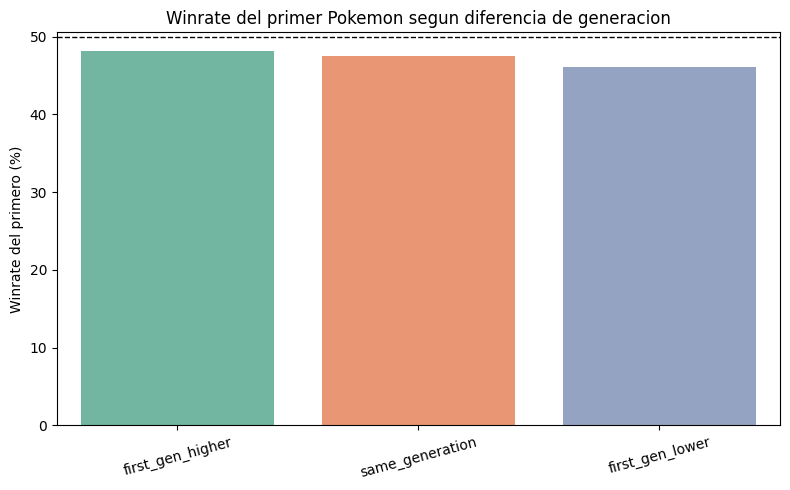

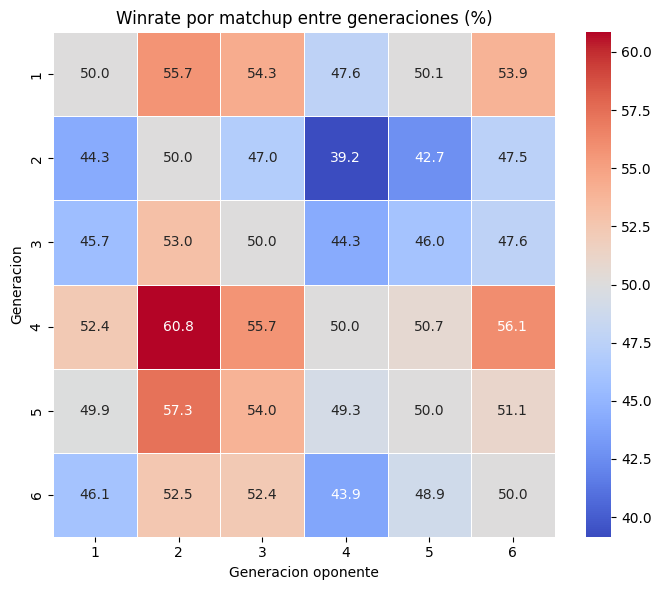

In [ ]:
# ---------- Funciones auxiliares ----------
try:
    wilson_ci
except NameError:
    def wilson_ci(successes, n, z=1.96):
        if n == 0:
            return np.nan, np.nan
        p_hat = successes / n
        denom = 1 + (z ** 2) / n
        center = (p_hat + (z ** 2) / (2 * n)) / denom
        margin = (z / denom) * np.sqrt((p_hat * (1 - p_hat) / n) + (z ** 2) / (4 * (n ** 2)))
        return center - margin, center + margin


def summarize_binary_advantage(df, advantage_col, label):
    n = len(df)
    wins = int(df[advantage_col].sum())
    p = wins / n if n > 0 else np.nan
    low, high = wilson_ci(wins, n)
    return {
        "comparison": label,
        "n_battles": n,
        "winrate_pct": p * 100 if n > 0 else np.nan,
        "ci95_low_pct": low * 100 if n > 0 else np.nan,
        "ci95_high_pct": high * 100 if n > 0 else np.nan,
    }


def make_directed_matrix(df, row_col, col_col, won_col="won"):
    directed = pd.concat(
        [
            df[[row_col, col_col, won_col]].rename(columns={row_col: "group", col_col: "opponent", won_col: "won"}),
            df[[col_col, row_col, won_col]]
            .assign(won=lambda d: 1 - d[won_col])
            .rename(columns={col_col: "group", row_col: "opponent"}),
        ],
        ignore_index=True,
    )
    winrate_matrix = directed.groupby(["group", "opponent"])["won"].mean().mul(100).unstack()
    count_matrix = directed.groupby(["group", "opponent"]).size().unstack().fillna(0).astype(int)
    return directed, winrate_matrix, count_matrix


# ---------- Base de combates deduplicada ----------
if "combat_model_df" not in locals():
    combat_model_df = combat_df.drop_duplicates(subset=["First_pokemon", "Second_pokemon", "Winner"]).copy()

analysis_df = combat_model_df[["First_pokemon", "Second_pokemon", "Winner"]].copy()
analysis_df["first_wins"] = (analysis_df["Winner"] == analysis_df["First_pokemon"]).astype(int)

pokedex_index = pokemon_df.set_index("#")
gen_lookup = pokedex_index["Generation"]
speed_lookup = pokedex_index["Speed"]
total_lookup = pokedex_index[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].sum(axis=1)

analysis_df["first_gen"] = analysis_df["First_pokemon"].map(gen_lookup)
analysis_df["second_gen"] = analysis_df["Second_pokemon"].map(gen_lookup)
analysis_df["diff_generation"] = analysis_df["first_gen"] - analysis_df["second_gen"]
analysis_df["diff_speed"] = analysis_df["First_pokemon"].map(speed_lookup) - analysis_df["Second_pokemon"].map(speed_lookup)
analysis_df["diff_total"] = analysis_df["First_pokemon"].map(total_lookup) - analysis_df["Second_pokemon"].map(total_lookup)

balanced_mask = analysis_df["diff_speed"].abs().le(5) & analysis_df["diff_total"].abs().le(30)
analysis_bal_df = analysis_df[balanced_mask].copy()

print(f"Combates para analisis de generacion (deduplicados): {len(analysis_df):,}")
print(f"Submuestra controlada (|diff_speed|<=5, |diff_total|<=30): {len(analysis_bal_df):,}")

# 1) Relacion entre diff_generation y first_wins
analysis_df["gen_adv_case"] = np.select(
    [analysis_df["diff_generation"] > 0, analysis_df["diff_generation"] == 0, analysis_df["diff_generation"] < 0],
    ["first_gen_higher", "same_generation", "first_gen_lower"],
    default="unknown",
)

gen_diff_summary = (
    analysis_df.groupby("gen_adv_case", observed=False)
    .agg(
        n_battles=("first_wins", "size"),
        first_winrate_pct=("first_wins", lambda s: s.mean() * 100),
    )
    .reindex(["first_gen_higher", "same_generation", "first_gen_lower"])
    .reset_index()
)

ci_lows, ci_highs = [], []
for _, row in gen_diff_summary.iterrows():
    n = int(row["n_battles"]) if not pd.isna(row["n_battles"]) else 0
    if n == 0:
        ci_lows.append(np.nan)
        ci_highs.append(np.nan)
    else:
        if row["gen_adv_case"] == "first_gen_higher":
            subset = analysis_df[analysis_df["diff_generation"] > 0]
        elif row["gen_adv_case"] == "same_generation":
            subset = analysis_df[analysis_df["diff_generation"] == 0]
        else:
            subset = analysis_df[analysis_df["diff_generation"] < 0]
        wins = int(subset["first_wins"].sum())
        low, high = wilson_ci(wins, n)
        ci_lows.append(low * 100)
        ci_highs.append(high * 100)

gen_diff_summary["ci95_low_pct"] = ci_lows
gen_diff_summary["ci95_high_pct"] = ci_highs

print("Win rate del primero segun ventaja de generacion")
display(gen_diff_summary.round(2))

# 2) Matriz generacion vs generacion
_, gen_winrate_matrix, gen_count_matrix = make_directed_matrix(
    analysis_df.rename(columns={"first_gen": "g1", "second_gen": "g2", "first_wins": "won"}),
    "g1",
    "g2",
    "won",
)

ordered_gens = sorted([g for g in gen_winrate_matrix.index if pd.notna(g)])
gen_winrate_matrix = gen_winrate_matrix.reindex(index=ordered_gens, columns=ordered_gens)
gen_count_matrix = gen_count_matrix.reindex(index=ordered_gens, columns=ordered_gens).fillna(0).astype(int)

print("Matriz de win rate dirigido por generacion (fila vs columna)")
display(gen_winrate_matrix.round(2))
print("Matriz de conteos por generacion")
display(gen_count_matrix)

# 3) Control parcial por confusores
analysis_bal_df["gen_advantaged_wins"] = np.where(
    analysis_bal_df["diff_generation"] > 0,
    analysis_bal_df["first_wins"],
    np.where(analysis_bal_df["diff_generation"] < 0, 1 - analysis_bal_df["first_wins"], np.nan),
)

gen_adv_bal = analysis_bal_df[analysis_bal_df["diff_generation"] != 0].copy()
gen_bal_summary = pd.DataFrame([
    summarize_binary_advantage(gen_adv_bal, "gen_advantaged_wins", "Higher generation wins (controlado)")
]).round(2)

print("Resumen controlado de ventaja por generacion")
display(gen_bal_summary)

# Visualizaciones de generacion
plt.figure(figsize=(8, 5))
sns.barplot(
    data=gen_diff_summary,
    x="gen_adv_case",
    y="first_winrate_pct",
    hue="gen_adv_case",
    palette="Set2",
    legend=False,
)
plt.axhline(50, color="black", linestyle="--", linewidth=1)
plt.title("Win rate del primer Pokemon segun diferencia de generacion")
plt.xlabel("")
plt.ylabel("Win rate del primero (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "generation_advantage_winrate_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 6))
sns.heatmap(gen_winrate_matrix, annot=True, fmt=".1f", cmap="coolwarm", center=50, linewidths=0.5)
plt.title("Win rate por matchup entre generaciones (%)")
plt.xlabel("Generacion oponente")
plt.ylabel("Generacion")
plt.tight_layout()
plt.savefig(FIG_DIR / "generation_matchup_heatmap_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusiones - Generation

- La diferencia de generación muestra una señal descriptiva **débil** sobre la probabilidad de victoria del primer Pokémon.
- En términos brutos, tener generación mayor del primero incrementa el winrate solo de forma marginal frente a tener generación menor.
- En el análisis controlado por `Speed` y `Stats_Total`, la ventaja de generación se aproxima a 50%, lo que sugiere que gran parte del efecto observado está mediado por stats.
- La matriz generación vs generación aporta contexto útil de enfrentamientos, pero su interpretación debe hacerse junto con los conteos por celda.
- Implicación para modelado: `Generation` puede mantenerse como feature auxiliar, con menor prioridad que variables relativas de stats (`diff_speed`, `diff_total`, etc.).

## Analisis de tipos (`Type 1` y `Type 2`), separado de generacion
Incluye matchups dirigidos, conteos, IC95 de Wilson y control parcial por confusores.

Combates para analisis de tipos (deduplicados): 48,048
Submuestra controlada (|diff_speed|<=5, |diff_total|<=30): 1,202
Matriz Type1 (tipos con n_total>=500)


opponent,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
group,,,,,,,,,,,,,,,,,
Bug,50.00,35.25,27.96,26.87,61.20,41.86,32.57,44.48,52.26,47.69,48.94,38.62,46.96,42.33,46.25,46.69,46.26
Dark,64.75,50.00,51.37,44.71,79.01,51.52,50.42,66.67,71.47,61.54,66.96,54.58,66.12,94.24,73.59,66.89,64.21
Dragon,72.04,48.63,50.00,54.02,11.11,66.96,56.91,68.28,70.07,68.89,68.97,56.83,69.70,52.63,75.20,78.99,71.48
Electric,73.13,55.29,45.98,50.00,82.11,68.57,59.75,75.48,66.89,9.57,71.07,61.60,72.02,56.40,70.86,71.29,69.58
Fairy,38.80,20.99,88.89,17.89,50.00,35.00,21.37,45.16,30.05,31.08,39.66,24.89,30.26,26.67,41.67,38.71,31.29
Fighting,58.14,48.48,33.04,31.43,65.00,50.00,35.85,13.28,55.04,49.59,58.14,43.40,56.80,36.00,68.25,59.46,45.41
Fire,67.43,49.58,43.09,40.25,78.63,64.15,50.00,63.75,70.24,52.36,68.85,54.06,66.19,48.62,60.82,68.44,58.35
Ghost,55.52,33.33,31.72,24.52,54.84,86.72,36.25,50.00,49.85,45.58,50.43,51.09,57.25,45.65,61.31,54.90,46.68
Grass,47.74,28.53,29.93,33.11,69.95,44.96,29.76,50.15,50.00,48.21,41.45,39.41,43.84,37.01,56.44,49.43,50.57


Conteos Type1 (tipos con n_total>=500)


opponent,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
group,,,,,,,,,,,,,,,,,
Bug,738,295,329,454,183,258,565,344,731,325,282,1028,313,619,467,272,1150
Dark,295,146,146,208,81,99,240,138,319,143,112,480,121,278,231,148,489
Dragon,329,146,146,174,81,115,246,145,304,135,116,461,165,266,250,138,561
Electric,454,208,174,258,123,175,323,208,441,209,159,651,193,406,278,202,687
Fairy,183,81,81,123,48,60,131,62,193,74,58,233,76,135,132,62,310
Fighting,258,99,115,175,60,126,212,128,258,123,86,424,125,225,189,111,458
Fire,565,240,246,323,131,212,416,240,531,254,183,825,210,434,342,225,898
Ghost,344,138,145,208,62,128,240,154,333,147,117,460,138,276,199,153,482
Grass,731,319,304,441,193,258,531,333,676,307,234,949,292,616,466,265,1143


Winrate dirigido por Type1 (n>=500)


,n_battles,winrate_pct
Type1,,
Water,13469,46.74
Normal,11603,53.87
Bug,8391,43.00
Grass,8093,43.82
Psychic,7054,54.72
Fire,6304,58.03
Rock,5444,40.63
Electric,5165,62.88
Dragon,3799,63.31


Top perfiles de tipo (Type1/Type2) por winrate, con n>=150


,n_battles,winrate_pct
TypeProfile,,
Dark/Ice,222,95.95
Normal/Fighting,239,95.82
Flying/None,228,90.79
Dragon/Psychic,356,87.36
Rock/Flying,499,86.57
Fighting/Steel,224,81.25
Psychic/Fighting,386,81.09
Electric/Flying,574,80.66
Dragon/Flying,772,80.57


Single vs dual-type


,comparison,n_battles,winrate_pct,ci95_low_pct,ci95_high_pct
0,Dual-type vs Single-type,24067,56.68,56.06,57.31
1,Dual-type vs Single-type (controlado),605,49.92,45.95,53.89


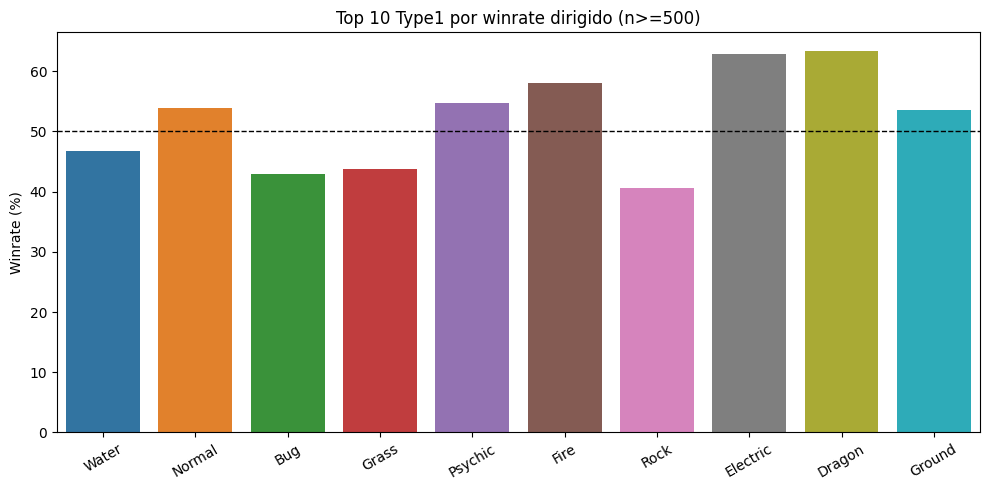

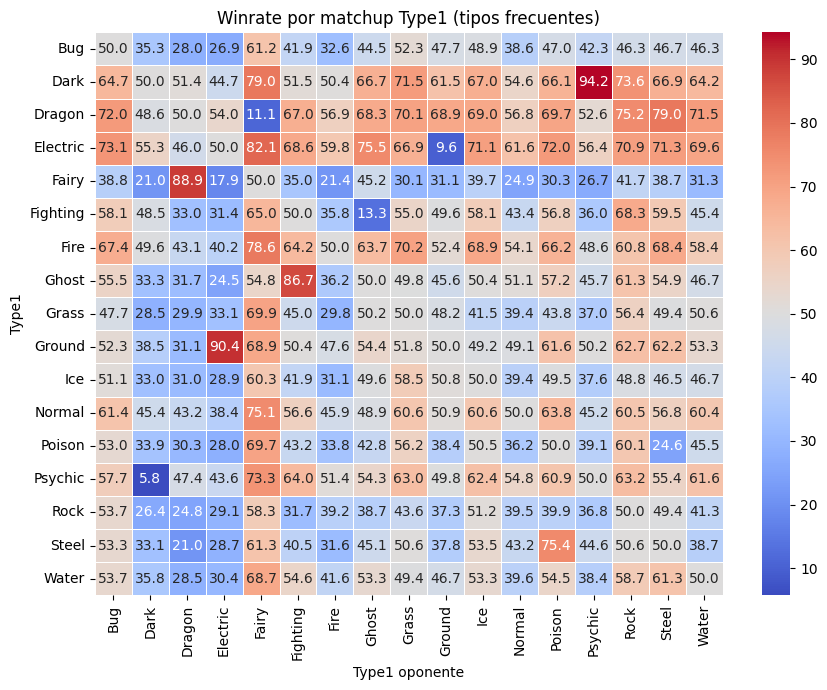

In [ ]:
# ---------- Funciones auxiliares de respaldo ----------
try:
    summarize_binary_advantage
except NameError:
    def wilson_ci(successes, n, z=1.96):
        if n == 0:
            return np.nan, np.nan
        p_hat = successes / n
        denom = 1 + (z ** 2) / n
        center = (p_hat + (z ** 2) / (2 * n)) / denom
        margin = (z / denom) * np.sqrt((p_hat * (1 - p_hat) / n) + (z ** 2) / (4 * (n ** 2)))
        return center - margin, center + margin

    def summarize_binary_advantage(df, advantage_col, label):
        n = len(df)
        wins = int(df[advantage_col].sum())
        p = wins / n if n > 0 else np.nan
        low, high = wilson_ci(wins, n)
        return {
            "comparison": label,
            "n_battles": n,
            "winrate_pct": p * 100 if n > 0 else np.nan,
            "ci95_low_pct": low * 100 if n > 0 else np.nan,
            "ci95_high_pct": high * 100 if n > 0 else np.nan,
        }

try:
    make_directed_matrix
except NameError:
    def make_directed_matrix(df, row_col, col_col, won_col="won"):
        directed = pd.concat(
            [
                df[[row_col, col_col, won_col]].rename(columns={row_col: "group", col_col: "opponent", won_col: "won"}),
                df[[col_col, row_col, won_col]]
                .assign(won=lambda d: 1 - d[won_col])
                .rename(columns={col_col: "group", row_col: "opponent"}),
            ],
            ignore_index=True,
        )
        winrate_matrix = directed.groupby(["group", "opponent"])["won"].mean().mul(100).unstack()
        count_matrix = directed.groupby(["group", "opponent"]).size().unstack().fillna(0).astype(int)
        return directed, winrate_matrix, count_matrix


# ---------- Base ----------
if "analysis_df" not in locals():
    if "combat_model_df" not in locals():
        combat_model_df = combat_df.drop_duplicates(subset=["First_pokemon", "Second_pokemon", "Winner"]).copy()
    analysis_df = combat_model_df[["First_pokemon", "Second_pokemon", "Winner"]].copy()
    analysis_df["first_wins"] = (analysis_df["Winner"] == analysis_df["First_pokemon"]).astype(int)
    pokedex_index = pokemon_df.set_index("#")
    speed_lookup = pokedex_index["Speed"]
    total_lookup = pokedex_index[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].sum(axis=1)
    analysis_df["diff_speed"] = analysis_df["First_pokemon"].map(speed_lookup) - analysis_df["Second_pokemon"].map(speed_lookup)
    analysis_df["diff_total"] = analysis_df["First_pokemon"].map(total_lookup) - analysis_df["Second_pokemon"].map(total_lookup)

if "analysis_bal_df" not in locals():
    analysis_bal_df = analysis_df[analysis_df["diff_speed"].abs().le(5) & analysis_df["diff_total"].abs().le(30)].copy()

pokedex_index = pokemon_df.set_index("#")
type1_lookup = pokedex_index["Type 1"]
type2_lookup = pokedex_index["Type 2"].fillna("None")

analysis_df["first_type1"] = analysis_df["First_pokemon"].map(type1_lookup)
analysis_df["second_type1"] = analysis_df["Second_pokemon"].map(type1_lookup)
analysis_df["first_type2"] = analysis_df["First_pokemon"].map(type2_lookup)
analysis_df["second_type2"] = analysis_df["Second_pokemon"].map(type2_lookup)
analysis_df["first_has_type2"] = analysis_df["first_type2"].ne("None")
analysis_df["second_has_type2"] = analysis_df["second_type2"].ne("None")

analysis_bal_df["first_type1"] = analysis_bal_df["First_pokemon"].map(type1_lookup)
analysis_bal_df["second_type1"] = analysis_bal_df["Second_pokemon"].map(type1_lookup)
analysis_bal_df["first_type2"] = analysis_bal_df["First_pokemon"].map(type2_lookup)
analysis_bal_df["second_type2"] = analysis_bal_df["Second_pokemon"].map(type2_lookup)
analysis_bal_df["first_has_type2"] = analysis_bal_df["first_type2"].ne("None")
analysis_bal_df["second_has_type2"] = analysis_bal_df["second_type2"].ne("None")

print(f"Combates para analisis de tipos (deduplicados): {len(analysis_df):,}")
print(f"Submuestra controlada (|diff_speed|<=5, |diff_total|<=30): {len(analysis_bal_df):,}")

# 1) Matriz de matchups de Type 1 (dirigida)
_, type1_winrate_matrix, type1_count_matrix = make_directed_matrix(
    analysis_df.rename(columns={"first_type1": "t1", "second_type1": "t2", "first_wins": "won"}),
    "t1",
    "t2",
    "won",
)

type1_total_counts = analysis_df["first_type1"].value_counts().add(analysis_df["second_type1"].value_counts(), fill_value=0)
common_types = type1_total_counts[type1_total_counts >= 500].index.tolist()

type1_winrate_common = type1_winrate_matrix.reindex(index=common_types, columns=common_types)
type1_count_common = type1_count_matrix.reindex(index=common_types, columns=common_types).fillna(0).astype(int)

print("Matriz de Type 1 (tipos con n_total>=500)")
display(type1_winrate_common.round(2))
print("Conteos de Type 1 (tipos con n_total>=500)")
display(type1_count_common)

# 2) Win rate historico por Type 1 (participacion dirigida)
type1_directed = pd.concat(
    [
        analysis_df[["first_type1", "first_wins"]].rename(columns={"first_type1": "Type1", "first_wins": "won"}),
        analysis_df[["second_type1", "first_wins"]]
        .assign(won=lambda d: 1 - d["first_wins"])
        .rename(columns={"second_type1": "Type1"}),
    ],
    ignore_index=True,
)

type1_summary = (
    type1_directed.groupby("Type1", observed=False)
    .agg(n_battles=("won", "size"), winrate_pct=("won", lambda s: s.mean() * 100))
    .sort_values("n_battles", ascending=False)
)
type1_summary = type1_summary[type1_summary["n_battles"] >= 500]

print("Win rate dirigido por Type 1 (n>=500)")
display(type1_summary.round(2).head(15))

# 3) Perfil de tipo (Type 1 + Type 2)
analysis_df["first_type_profile"] = analysis_df["first_type1"].astype(str) + "/" + analysis_df["first_type2"].astype(str)
analysis_df["second_type_profile"] = analysis_df["second_type1"].astype(str) + "/" + analysis_df["second_type2"].astype(str)

profile_directed = pd.concat(
    [
        analysis_df[["first_type_profile", "first_wins"]].rename(columns={"first_type_profile": "TypeProfile", "first_wins": "won"}),
        analysis_df[["second_type_profile", "first_wins"]]
        .assign(won=lambda d: 1 - d["first_wins"])
        .rename(columns={"second_type_profile": "TypeProfile"}),
    ],
    ignore_index=True,
)

profile_summary = (
    profile_directed.groupby("TypeProfile", observed=False)
    .agg(n_battles=("won", "size"), winrate_pct=("won", lambda s: s.mean() * 100))
    .query("n_battles >= 150")
    .sort_values(["winrate_pct", "n_battles"], ascending=[False, False])
)

print("Top perfiles de tipo (Type 1/Type 2) por win rate, con n>=150")
display(profile_summary.head(15).round(2))

# 4) Single vs dual-type y control parcial
single_dual_df = analysis_df[analysis_df["first_has_type2"] != analysis_df["second_has_type2"]].copy()
single_dual_df["dual_adv_wins"] = np.where(single_dual_df["first_has_type2"], single_dual_df["first_wins"], 1 - single_dual_df["first_wins"])

single_dual_summary = pd.DataFrame([
    summarize_binary_advantage(single_dual_df, "dual_adv_wins", "Dual-type vs Single-type")
]).round(2)

single_dual_bal_df = analysis_bal_df[analysis_bal_df["first_has_type2"] != analysis_bal_df["second_has_type2"]].copy()
single_dual_bal_df["dual_adv_wins"] = np.where(single_dual_bal_df["first_has_type2"], single_dual_bal_df["first_wins"], 1 - single_dual_bal_df["first_wins"])

single_dual_bal_summary = pd.DataFrame([
    summarize_binary_advantage(single_dual_bal_df, "dual_adv_wins", "Dual-type vs Single-type (controlado)")
]).round(2)

print("Single vs dual-type")
display(pd.concat([single_dual_summary, single_dual_bal_summary], ignore_index=True))

# 5) Visualizaciones de tipos
plt.figure(figsize=(10, 5))
plot_type1 = type1_summary.reset_index().head(10)
sns.barplot(
    data=plot_type1,
    x="Type1",
    y="winrate_pct",
    hue="Type1",
    palette="tab10",
    legend=False,
)
plt.axhline(50, color="black", linestyle="--", linewidth=1)
plt.title("Top 10 de Type 1 por win rate dirigido (n>=500)")
plt.xlabel("")
plt.ylabel("Win rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "type1_top10_winrate_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(type1_winrate_common, annot=True, fmt=".1f", cmap="coolwarm", center=50, linewidths=0.4)
plt.title("Win rate por matchup de Type 1 (tipos frecuentes)")
plt.xlabel("Type 1 oponente")
plt.ylabel("Type 1")
plt.tight_layout()
plt.savefig(FIG_DIR / "type1_matchup_heatmap_corrected.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusiones - Types

- `Type1` muestra asociaciones descriptivas relevantes con el resultado, especialmente en análisis de matchups dirigidos.
- Las matrices de tipos deben leerse siempre junto con la matriz de conteos (`n`) para evitar interpretaciones espurias en celdas poco frecuentes.
- Los perfiles `Type1/Type2` permiten detectar combinaciones competitivas fuertes, pero varias corresponden a nichos de muestra y requieren validación adicional.
- La ventaja bruta de `dual-type` frente a `single-type` disminuye al controlar por `Speed` y `Stats_Total`, lo que indica confusión por atributos base.
- Implicación para modelado: incluir tipos como features relacionales (interacciones entre oponentes) y evaluar su contribución incremental con pruebas de ablation.

## Hallazgos clave sobre la variable objetivo

- La variable objetivo esta moderadamente balanceada y no requiere un rebalanceo inmediato de clases.
- Los combates duplicados introducen dependencia y deben removerse antes del entrenamiento.
- Las metricas historicas derivadas del resultado, como `WinRate`, son validas para EDA pero no para entrenamiento.
- Las variables relativas de combate, especialmente `diff_speed` y `diff_total`, son las señales mas fuertes del notebook.
- Las etiquetas de grupo (`Legendary`, `is_mega`) y las variables contextuales (`Generation`, `Type`) deben tratarse como predictores secundarios y ajustados.

## Resumen de relevancia de features

- Las features de mayor prioridad para el modelado son las diferencias relativas entre oponentes, especialmente `diff_speed` y `diff_total`.
- Las diferencias ofensivas como `diff_attack` y `diff_sp_atk` aportan señal adicional relevante y deberian formar parte del conjunto base de predictores.
- Variables de grupo como `Legendary` e `is_mega` pueden aportar señal incremental, pero no deben desplazar a las diferencias de stats como explicacion principal del resultado.
- `Generation` parece una variable contextual de baja prioridad una vez consideradas las stats.
- `Type` debe interpretarse mejor como informacion relacional o de interaccion entre oponentes que como un ranking aislado de categorias.
- Variables historicas derivadas del target (`WinRate`, `Wins`, `n_combats`) quedan excluidas del entrenamiento por riesgo de leakage.

## Riesgos para la validez del modelado

- El principal riesgo metodologico es el leakage por uso de metricas historicas calculadas con toda la base de combates, como `WinRate`, `Wins` y `n_combats`.
- Los duplicados exactos y los matchups repetidos pueden inflar artificialmente el rendimiento si no se controlan en el split.
- Parte de la señal aparente de `Legendary`, `is_mega`, `Generation` y `Type` puede estar mediada por diferencias de stats base, por lo que no debe interpretarse como efecto neto sin ajuste.
- Las combinaciones raras de tipos presentan riesgo de sparsity y de sobreinterpretacion.
- La fuerza extrema observada en `Speed` exige validar que no exista un sesgo de construccion del dataset o una regla implicita que exagere su peso real.
- El cierre del notebook debe mantener una distincion estricta entre hallazgos descriptivos, hallazgos robustos y decisiones de pipeline.

## Decisiones finales de preprocesamiento

### Limpieza de datos
- Remover duplicados exactos de combate.
- Conservar todas las filas de `pokemon_df`; no se detectaron inconsistencias estructurales de IDs.
- Tratar la ausencia de `Type 2` como ausencia explicita de segundo tipo y no como missing aleatorio.

### Definicion del target
- Modelar `first_wins` como variable supervisada.

### Conjunto de features
- Nucleo: diferencias relativas de stats.
- Secundarias: indicadores de legendario/mega, generacion e interacciones de tipos.
- Excluir variables historicas propensas a leakage.

### Diseño de validacion
- Usar un split consciente de leakage y de matchups repetidos.
- Realizar analisis de sensibilidad con y sin combates duplicados.

## Resumen tecnico ejecutivo

- El dataset es estructuralmente consistente, pero presenta un problema de calidad relevante: combates repetidos.
- La variable objetivo esta bien definida y muestra un balance razonable.
- Las diferencias relativas de stats son la señal predictiva dominante, especialmente `diff_speed`.
- Las ventajas historicas de grupos como `Legendary`, `Mega` y `dual-type` se debilitan de forma importante tras un control parcial por confusores.
- `Generation` parece debil despues del ajuste, mientras que `Type` se interpreta mejor como informacion relacional de matchup.
- El modelo final deberia priorizar features relativas de combate y excluir variables historicas que introduzcan leakage.